## Argument Precision and Recall

This figure follows the compact precision/recall style: each model has one bar
per dataset. Orange shows recall; blue shows the part of precision that is above
recall. The top of the bar is therefore the larger of precision and recall.

In [1]:
import sys
from pathlib import Path

search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(
    (path for path in search_roots if (path / "src/eval/read_eval.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Project root not found. Start Jupyter inside the llm-action-extraction repository.")
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import matplotlib.pyplot as plt
import numpy as np
from eval.read_eval import (
    DOMAIN_LABELS,
    DOMAIN_ORDER,
    METHOD_LABELS,
    MODEL_LABELS,
    MODEL_ORDER,
    read_eval_results,
)
from utils.helpers import find_project_root


ROOT = find_project_root()
RESULT_ROOT = ROOT / "results"

result_df = read_eval_results(
    RESULT_ROOT,
    domain_labels=DOMAIN_LABELS,
    method_labels=METHOD_LABELS,
    model_order=MODEL_ORDER,
)

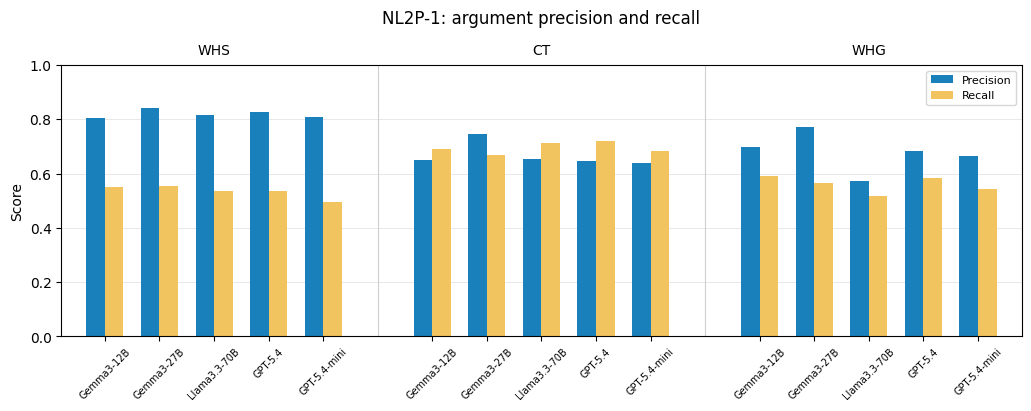

In [2]:
METHOD_KEY = "nl2p_1"
METRIC = "Argument"

panel_df = result_df[result_df["method"].astype(str) == METHOD_KEY]
models = [model for model in MODEL_ORDER if model in set(panel_df["model"].astype(str))]
model_labels = [MODEL_LABELS.get(model, model) for model in models]

bar_width = 0.34
group_gap = 1.0
x = []
x_labels = []
domain_centers = []
precision_values = []
recall_values = []

for domain_idx, domain in enumerate(DOMAIN_ORDER):
    start = domain_idx * (len(models) + group_gap)
    domain_x = []

    for model_idx, model in enumerate(models):
        xpos = start + model_idx
        domain_x.append(xpos)
        x.append(xpos)
        x_labels.append(model_labels[model_idx])

        row = panel_df[
            (panel_df["domain"].astype(str) == domain)
            & (panel_df["model"].astype(str) == model)
        ]
        precision_values.append(np.nan if row.empty else float(row.iloc[0][f"{METRIC} Precision"]))
        recall_values.append(np.nan if row.empty else float(row.iloc[0][f"{METRIC} Recall"]))

    domain_centers.append(np.mean(domain_x))

fig, ax = plt.subplots(figsize=(10.2, 4), constrained_layout=True)
ax.bar(
    np.array(x) - bar_width / 2,
    precision_values,
    width=bar_width,
    color="#1a80bb",
    edgecolor="none",
    label="Precision",
)
ax.bar(
    np.array(x) + bar_width / 2,
    recall_values,
    width=bar_width,
    color="#f2c45f",
    edgecolor="none",
    label="Recall",
)

for center, domain in zip(domain_centers, DOMAIN_ORDER):
    ax.text(center, 1.03, DOMAIN_LABELS[domain], ha="center", va="bottom", fontsize=10)

for left, right in zip(domain_centers, domain_centers[1:]):
    ax.axvline((left + right) / 2, color="#cfcfcf", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, fontsize=7)
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.0)
ax.set_xlim(min(x) - 0.8, max(x) + 0.8)
ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)
ax.legend(loc="upper right", frameon=True, fontsize=8)
ax.set_title(f"{METHOD_LABELS[METHOD_KEY]}: {METRIC.lower()} precision and recall", pad=30)
plt.show()
